In [31]:
import numpy as np 

def sigmoid(x):
    return 1/(1 + np.exp(-x))

def sigmoid_dev(x):
    s = sigmoid(x)
    return s * (1 - s)   # This value gives you how open the gate is (0 - 0.25 range?)


x = np.array([1.0])
y = np.array([1.0])

w1 = np.array([0.5])     # weight layer 1
b1 = np.array([0.0])
w2 = np.array([0.8])     # weight layer 2
b2 = np.array([0.0])

lr = 0.1 
epochs = 100 

print("Starting Training : ")

for epoch in range(epochs) :
    z1 = w1 * x + b1
    a1 = sigmoid(z1)
    z2 = w2 * a1 + b2
    output = sigmoid(z2)

    loss = np.mean((output - y) ** 2)

    dL_doutput = 2 * ( output - y )          # Gradient of loss 
    dL_dz2 = dL_doutput * sigmoid_dev(z2)    # (Gradient) How much blame reaches the output neurons Input 
    dL_dw2 = dL_dz2 * a1 
    dL_db2 = dL_dz2                          # This is for w2 and b2 

    dL_da1 = dL_dz2 * w2                     # Passing gradient back through w2 
    dL_dz1 = dL_da1 * sigmoid_dev(z1)
    dL_dw1 = dL_dz1 * x 
    dL_db1 = dL_dz1 

    w2 = w2 - lr * dL_dw2
    b2 = b2 - lr * dL_db2
    w1 = w1 - lr * dL_dw1
    b1 = b1 - lr * dL_db1

    print("Epoch : " , epoch+1 ,"  | Loss : " , round(loss,5) , "  | Output : " , output, " | w1 : " , w1 , "  | w2 : ", w2)
    # Every single epoch is one complete forward pass + backward pass + weight update

print("Final Output : ", output)




Starting Training : 
Epoch :  1   | Loss :  0.1429   | Output :  [0.62198156]  | w1 :  [0.50334194]   | w2 :  [0.81106482]
Epoch :  2   | Loss :  0.13834   | Output :  [0.62806014]  | w1 :  [0.50664861]   | w2 :  [0.82190862]
Epoch :  3   | Loss :  0.13397   | Output :  [0.63397825]  | w1 :  [0.50991888]   | w2 :  [0.83253536]
Epoch :  4   | Loss :  0.12979   | Output :  [0.63973893]  | w1 :  [0.5131518]   | w2 :  [0.84294921]
Epoch :  5   | Loss :  0.12578   | Output :  [0.64534542]  | w1 :  [0.51634658]   | w2 :  [0.85315442]
Epoch :  6   | Loss :  0.12194   | Output :  [0.65080113]  | w1 :  [0.51950261]   | w2 :  [0.86315536]
Epoch :  7   | Loss :  0.11826   | Output :  [0.65610957]  | w1 :  [0.52261939]   | w2 :  [0.87295648]
Epoch :  8   | Loss :  0.11474   | Output :  [0.66127438]  | w1 :  [0.52569658]   | w2 :  [0.88256225]
Epoch :  9   | Loss :  0.11136   | Output :  [0.66629924]  | w1 :  [0.52873396]   | w2 :  [0.89197718]
Epoch :  10   | Loss :  0.10812   | Output :  [0.67118

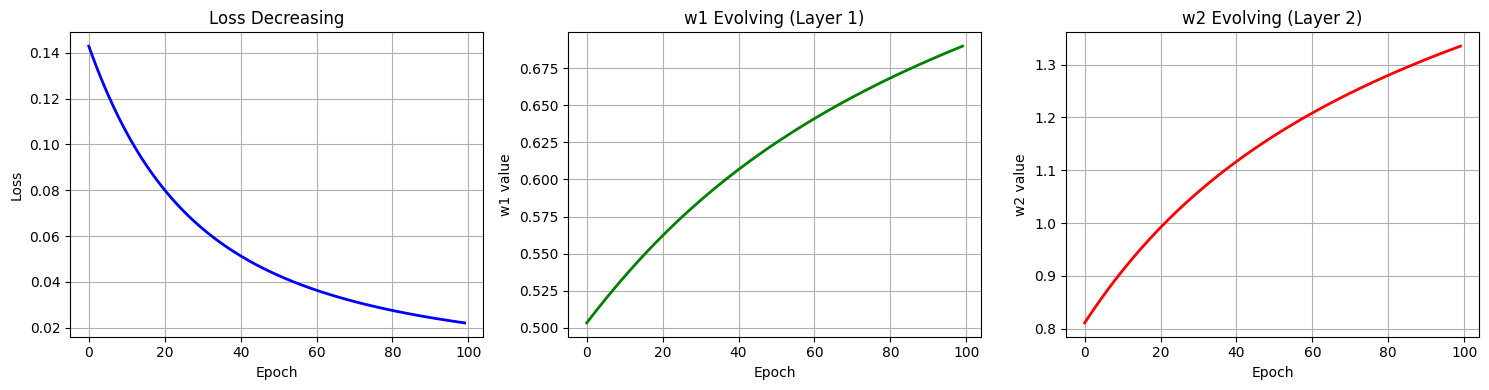

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

x  = np.array([1.0])
y  = np.array([1.0])
w1 = np.array([0.5])
b1 = np.array([0.0])
w2 = np.array([0.8])
b2 = np.array([0.0])
lr = 0.1

loss_hist = []
w1_hist   = []
w2_hist   = []

for _ in range(100):
    # Forward
    z1     = w1 * x + b1
    a1     = sigmoid(z1)
    z2     = w2 * a1 + b2
    output = sigmoid(z2)
    loss   = np.mean((output - y) ** 2)

    # Backward
    dL_doutput = 2 * (output - y)
    dL_dz2     = dL_doutput * sigmoid_derivative(z2)
    dL_dw2     = dL_dz2 * a1
    dL_db2     = dL_dz2
    dL_da1     = dL_dz2 * w2
    dL_dz1     = dL_da1 * sigmoid_derivative(z1)
    dL_dw1     = dL_dz1 * x
    dL_db1     = dL_dz1

    # Update
    w2 = w2 - lr * dL_dw2
    b2 = b2 - lr * dL_db2
    w1 = w1 - lr * dL_dw1
    b1 = b1 - lr * dL_db1

    loss_hist.append(float(loss))   
    w1_hist.append(float(w1[0]))    
    w2_hist.append(float(w2[0]))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_hist, 'b-', linewidth=2)
axes[0].set_title("Loss Decreasing")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(w1_hist, 'g-', linewidth=2)
axes[1].set_title("w1 Evolving (Layer 1)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("w1 value")
axes[1].grid(True)

axes[2].plot(w2_hist, 'r-', linewidth=2)
axes[2].set_title("w2 Evolving (Layer 2)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("w2 value")
axes[2].grid(True)

plt.tight_layout()
plt.show()


Starting Training : 
Epoch :  1   | Loss :  0.16628   | Output :  [0.59222931]  | w1 :  [0.50052235]   | w2 :  [0.80172944]   | w3 :  [0.61224981]
Epoch :  2   | Loss :  0.16084   | Output :  [0.59894852]  | w1 :  [0.50104426]   | w2 :  [0.80345484]   | w3 :  [0.62425203]
Epoch :  3   | Loss :  0.15563   | Output :  [0.60549682]  | w1 :  [0.50156527]   | w2 :  [0.80517466]   | w3 :  [0.63601037]
Epoch :  4   | Loss :  0.15064   | Output :  [0.61187629]  | w1 :  [0.50208493]   | w2 :  [0.80688748]   | w3 :  [0.64752882]
Epoch :  5   | Loss :  0.14586   | Output :  [0.61808938]  | w1 :  [0.50260284]   | w2 :  [0.80859204]   | w3 :  [0.65881165]
Epoch :  6   | Loss :  0.14127   | Output :  [0.62413885]  | w1 :  [0.50311866]   | w2 :  [0.81028718]   | w3 :  [0.66986331]
Epoch :  7   | Loss :  0.13688   | Output :  [0.63002774]  | w1 :  [0.50363204]   | w2 :  [0.81197189]   | w3 :  [0.68068843]
Epoch :  8   | Loss :  0.13267   | Output :  [0.63575931]  | w1 :  [0.50414269]   | w2 :  [0.8136

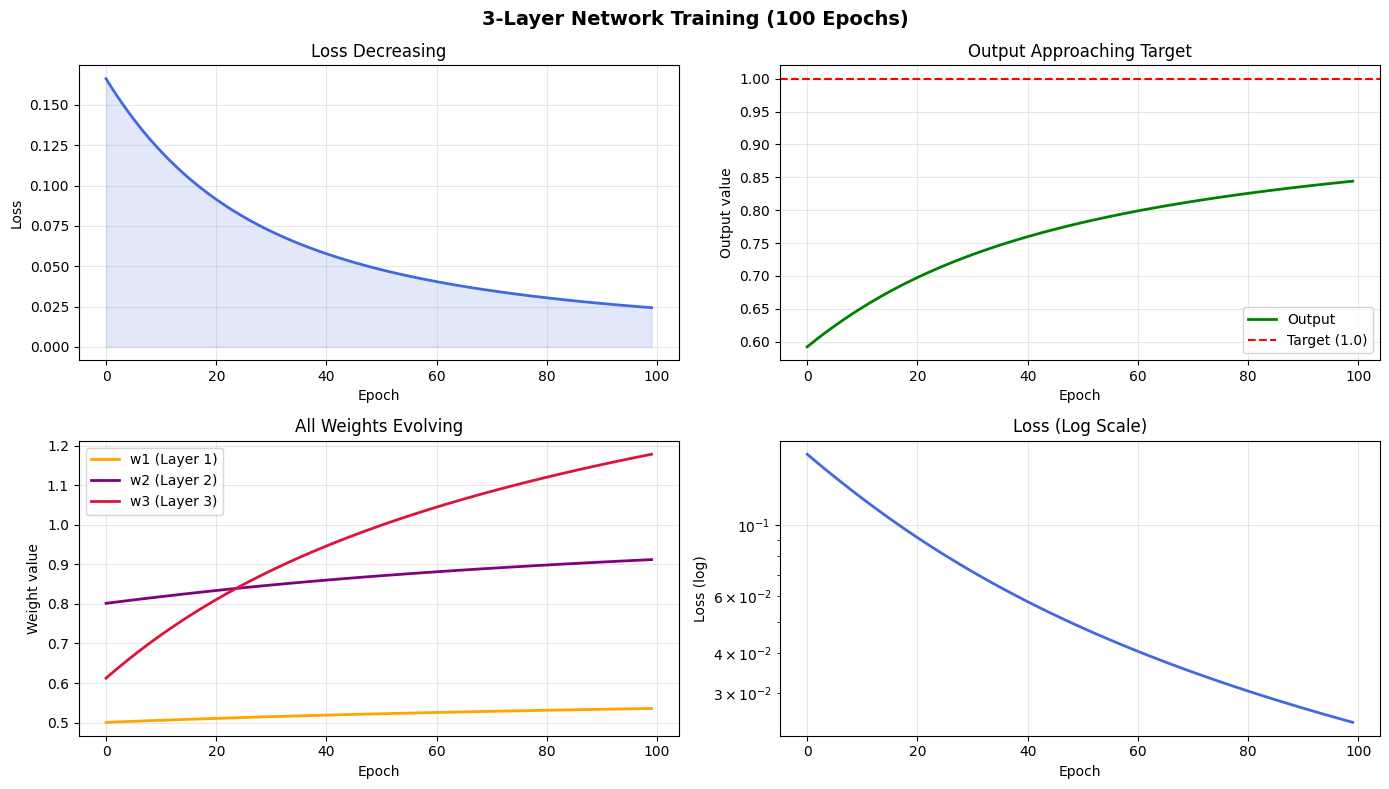

In [32]:
import numpy as np 
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1 + np.exp(-x))

def sigmoid_dev(x):
    s = sigmoid(x)
    return s * (1 - s)   # This value gives you how open the gate is (0 - 0.25 range?)


x = np.array([1.0])
y = np.array([1.0])

w1 = np.array([0.5])     # weight layer 1
b1 = np.array([0.0])
w2 = np.array([0.8])     # weight layer 2
b2 = np.array([0.0])
w3 = np.array([0.6])     # weight layer 3
b3 = np.array([0.0])

lr = 0.1 
epochs = 100

loss_hist = []
w1_hist   = []
w2_hist   = []
w3_hist   = []
out_hist  = []

print("Starting Training : ")

for epoch in range(epochs) :
    z1 = w1 * x + b1
    a1 = sigmoid(z1)
    z2 = w2 * a1 + b2
    a2 = sigmoid(z2)
    z3 = w3 * a2 + b3
    output = sigmoid(z3)

    loss = np.mean((output - y) ** 2)

    dL_doutput = 2 * ( output - y )          # Gradient of loss 
    dL_dz3 = dL_doutput * sigmoid_dev(z3)    # (Gradient) How much blame reaches the output neurons Input 
    dL_dw3 = dL_dz3 * a2 
    dL_db3 = dL_dz3                          # This is for w3 and b3 

    dL_da2 = dL_dz3 * w3                     # Passing gradient back through w3 
    dL_dz2 = dL_da2 * sigmoid_dev(z2)
    dL_dw2 = dL_dz2 * a1
    dL_db2 = dL_dz2 

    dL_da1 = dL_dz2 * w2                     # Passing gradient back through w2 
    dL_dz1 = dL_da1 * sigmoid_dev(z1)
    dL_dw1 = dL_dz1 * x 
    dL_db1 = dL_dz1 

    w3 = w3 - lr * dL_dw3                    # Weight Update
    b3 = b3 - lr * dL_db3
    w2 = w2 - lr * dL_dw2
    b2 = b2 - lr * dL_db2
    w1 = w1 - lr * dL_dw1
    b1 = b1 - lr * dL_db1

    loss_hist.append(float(loss))
    w1_hist.append(float(w1[0]))
    w2_hist.append(float(w2[0]))
    w3_hist.append(float(w3[0]))
    out_hist.append(float(output[0]))
    print("Epoch : " , epoch+1 ,"  | Loss : " , round(loss,5) , "  | Output : " , output, " | w1 : " , w1 , "  | w2 : ", w2 , "  | w3 : ", w3)
    # Every single epoch is one complete forward pass + backward pass + weight update

print("Final Output : ", output)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("3-Layer Network Training (100 Epochs)", fontsize=14, fontweight='bold')

# Plot 1 — Loss
axes[0,0].plot(loss_hist, color='royalblue', linewidth=2)
axes[0,0].fill_between(range(len(loss_hist)), loss_hist, alpha=0.15, color='royalblue')
axes[0,0].set_title("Loss Decreasing")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].grid(True, alpha=0.3)

# Plot 2 — Output vs Target
axes[0,1].plot(out_hist, color='green', linewidth=2, label='Output')
axes[0,1].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Target (1.0)')
axes[0,1].set_title("Output Approaching Target")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Output value")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3 — All weights evolving
axes[1,0].plot(w1_hist, color='orange',  linewidth=2, label='w1 (Layer 1)')
axes[1,0].plot(w2_hist, color='purple',  linewidth=2, label='w2 (Layer 2)')
axes[1,0].plot(w3_hist, color='crimson', linewidth=2, label='w3 (Layer 3)')
axes[1,0].set_title("All Weights Evolving")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Weight value")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4 — Loss on log scale (shows rate of learning)
axes[1,1].plot(loss_hist, color='royalblue', linewidth=2)
axes[1,1].set_yscale('log')
axes[1,1].set_title("Loss (Log Scale)")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Loss (log)")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

